# Diabetes Predictor

In [72]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


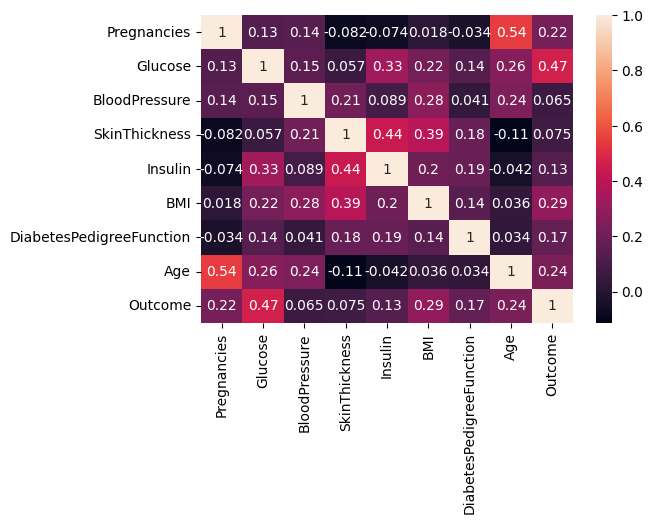

In [73]:
#Correlation  Heat-Map
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [74]:
#Train & Test Split
x=df.drop("Outcome",axis=1)  #data
y=df["Outcome"]              #output

scaler=StandardScaler()
x=scaler.fit_transform(x)         #Standardization

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


In [75]:
#Model Training
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [76]:
#Accuracy Score
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy of Model:",accuracy)

Accuracy of Model: 0.7142857142857143


In [77]:
#Prediction System
input_data=(2,197,70,45,543,30.5,0.158,53)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
data =scaler.transform(input_data_reshaped)
prediction=model.predict(data)
if(prediction[0]==1):
  print("Diabetic")
else:
  print("Non-Diabetic")


Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [78]:
import joblib

joblib.dump(model, "diabetes_model.pkl")

print("Model Saved")

Model Saved
